In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"]:
    install(pkg)

print(" All packages ready!")

 All packages ready!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import csv
import os
import random
from datetime import datetime, timedelta

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print(" All imports successful!")

 All imports successful!


In [3]:
def generate_dataset(n_samples=600):
    """
    Generates structured PPE compliance dataset.
    Features:
        helmet_present    : 0 or 1
        mask_present      : 0 or 1
        helmet_score      : float 0.0 - 1.0
        mask_score        : float 0.0 - 1.0
        violations_count  : 0, 1, 2, or 3
        people_count      : 1 to 5
        compliance_score  : float 0.0 - 1.0
    Risk Labels:
        Safe      -> both helmet and mask present, no violations
        Unsafe    -> one PPE missing
        High Risk -> both PPE missing or 2+ violations
    """
    records = []

    for _ in range(n_samples):
        people_count = random.randint(1, 5)
        helmet_present = random.choice([1, 1, 1, 0])   
        mask_present   = random.choice([1, 1, 1, 0])   

        helmet_score = round(random.uniform(0.7, 1.0) if helmet_present else random.uniform(0.0, 0.4), 2)
        mask_score   = round(random.uniform(0.7, 1.0) if mask_present   else random.uniform(0.0, 0.4), 2)

        violations_count = (1 - helmet_present) + (1 - mask_present)
        violations_count = min(violations_count + random.choice([0, 0, 0, 1]), 3)

        compliance_score = round((helmet_score + mask_score) / 2, 2)

        # Label assignment
        if helmet_present == 1 and mask_present == 1 and violations_count == 0:
            risk_label = "Safe"
        elif violations_count >= 2 or (helmet_present == 0 and mask_present == 0):
            risk_label = "High Risk"
        else:
            risk_label = "Unsafe"

        records.append({
            "helmet_present": helmet_present,
            "mask_present": mask_present,
            "helmet_score": helmet_score,
            "mask_score": mask_score,
            "violations_count": violations_count,
            "people_count": people_count,
            "compliance_score": compliance_score,
            "risk_label": risk_label
        })

    df = pd.DataFrame(records)
    return df


df = generate_dataset(600)
print(f" Dataset generated: {df.shape[0]} samples, {df.shape[1]} columns")
print("\n Risk Label Distribution:")
print(df['risk_label'].value_counts())
print("\n Sample Data:")
df.head(8)

 Dataset generated: 600 samples, 8 columns

 Risk Label Distribution:
risk_label
Unsafe       257
Safe         247
High Risk     96
Name: count, dtype: int64

 Sample Data:


,helmet_present,mask_present,helmet_score,mask_score,violations_count,people_count,compliance_score,risk_label
0,1,1,0.77,0.74,0,1,0.76,Safe
1,1,0,0.71,0.04,1,5,0.38,Unsafe
2,1,1,0.91,0.91,1,5,0.91,Unsafe
3,0,1,0.32,0.70,1,2,0.51,Unsafe
4,1,1,0.75,0.99,0,4,0.87,Safe
5,1,0,0.73,0.34,1,1,0.54,Unsafe
6,0,1,0.39,0.81,1,1,0.60,Unsafe
7,1,1,0.91,0.71,0,5,0.81,Safe


In [4]:
FEATURE_COLS = [
    'helmet_present', 'mask_present', 'helmet_score',
    'mask_score', 'violations_count', 'people_count', 'compliance_score'
]
TARGET_COL = 'risk_label'

assert df[FEATURE_COLS + [TARGET_COL]].isnull().sum().sum() == 0, "Missing values found!"
print(" No missing values — dataset is clean.")

X = df[FEATURE_COLS]
y = df[TARGET_COL]

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"\n  Label Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f"\n Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

train_dist = pd.Series(le.inverse_transform(y_train)).value_counts()
test_dist  = pd.Series(le.inverse_transform(y_test)).value_counts()
print("\nTrain distribution:")
print(train_dist)
print("\nTest distribution:")
print(test_dist)

 No missing values — dataset is clean.

  Label Encoding: {'High Risk': np.int64(0), 'Safe': np.int64(1), 'Unsafe': np.int64(2)}

 Train size: 480 | Test size: 120

Train distribution:
Unsafe       206
Safe         197
High Risk     77
Name: count, dtype: int64

Test distribution:
Unsafe       51
Safe         50
High Risk    19
Name: count, dtype: int64


In [5]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, average='weighted')
lr_rec  = recall_score(y_test, lr_pred, average='weighted')
lr_f1   = f1_score(y_test, lr_pred, average='weighted')

print(" Logistic Regression Performance")
print("-" * 40)
print(f"  Accuracy  : {lr_acc * 100:.2f}%")
print(f"  Precision : {lr_prec * 100:.2f}%")
print(f"  Recall    : {lr_rec * 100:.2f}%")
print(f"  F1 Score  : {lr_f1 * 100:.2f}%")
print()
print(classification_report(y_test, lr_pred, target_names=le.classes_))

 Logistic Regression Performance
----------------------------------------
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1 Score  : 100.00%

              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00        19
        Safe       1.00      1.00      1.00        50
      Unsafe       1.00      1.00      1.00        51

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted')
rf_rec  = recall_score(y_test, rf_pred, average='weighted')
rf_f1   = f1_score(y_test, rf_pred, average='weighted')

print(" Random Forest Performance")
print("-" * 40)
print(f"  Accuracy  : {rf_acc * 100:.2f}%")
print(f"  Precision : {rf_prec * 100:.2f}%")
print(f"  Recall    : {rf_rec * 100:.2f}%")
print(f"  F1 Score  : {rf_f1 * 100:.2f}%")
print()
print(classification_report(y_test, rf_pred, target_names=le.classes_))

 Random Forest Performance
----------------------------------------
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1 Score  : 100.00%

              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00        19
        Safe       1.00      1.00      1.00        50
      Unsafe       1.00      1.00      1.00        51

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



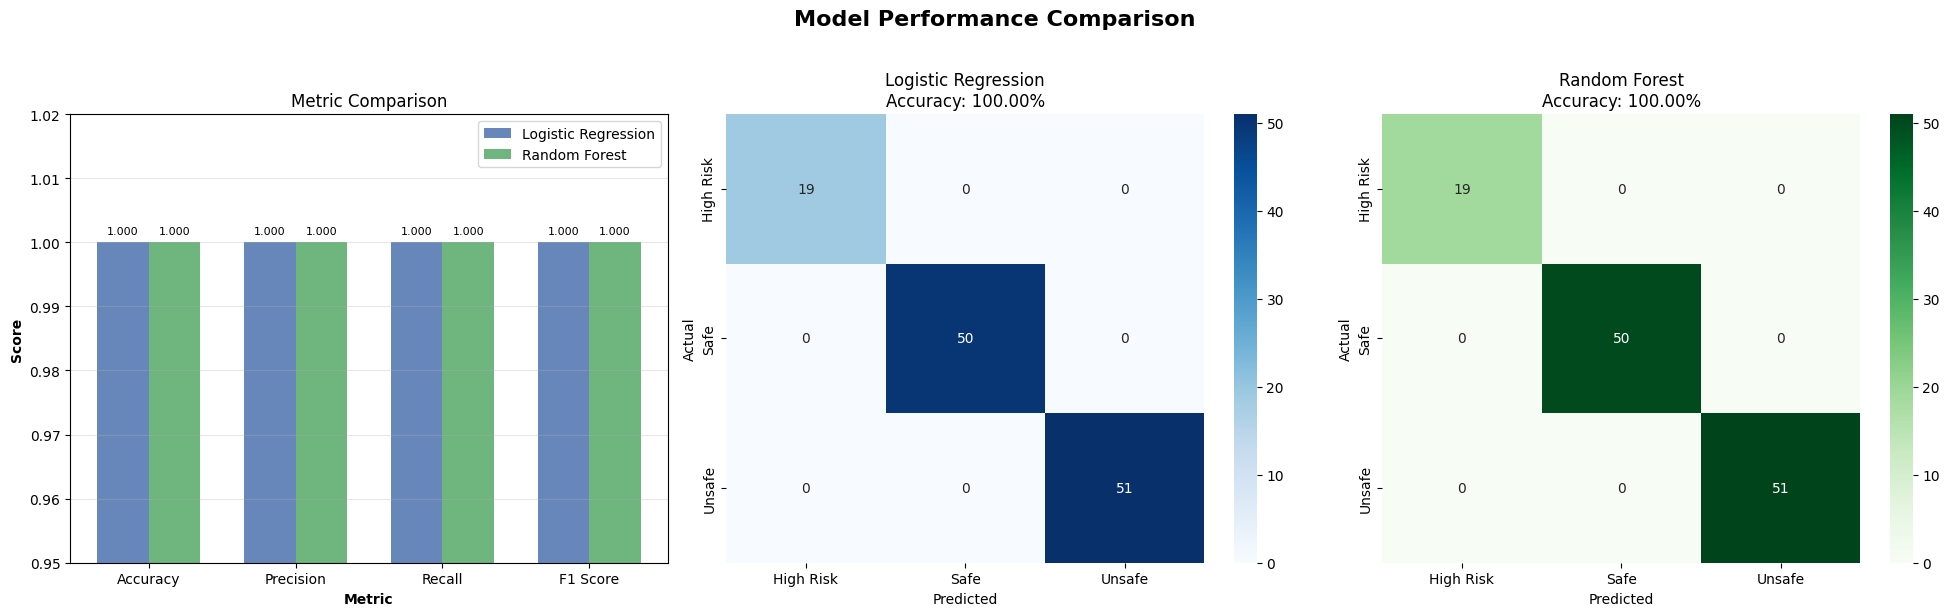

 Plot saved as model_comparison.png


In [7]:
models  = ['Logistic Regression', 'Random Forest']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

lr_scores = [lr_acc, lr_prec, lr_rec, lr_f1]
rf_scores = [rf_acc, rf_prec, rf_rec, rf_f1]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

ax = axes[0]
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest',       color='#55A868', alpha=0.85)
ax.set_xlabel('Metric', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Metric Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.95, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

cm_lr = confusion_matrix(y_test, lr_pred)
ax2 = axes[1]
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title(f'Logistic Regression\nAccuracy: {lr_acc*100:.2f}%')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# --- Confusion Matrix: Random Forest ---
cm_rf = confusion_matrix(y_test, rf_pred)
ax3 = axes[2]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax3)
ax3.set_title(f'Random Forest\nAccuracy: {rf_acc*100:.2f}%')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved as model_comparison.png")

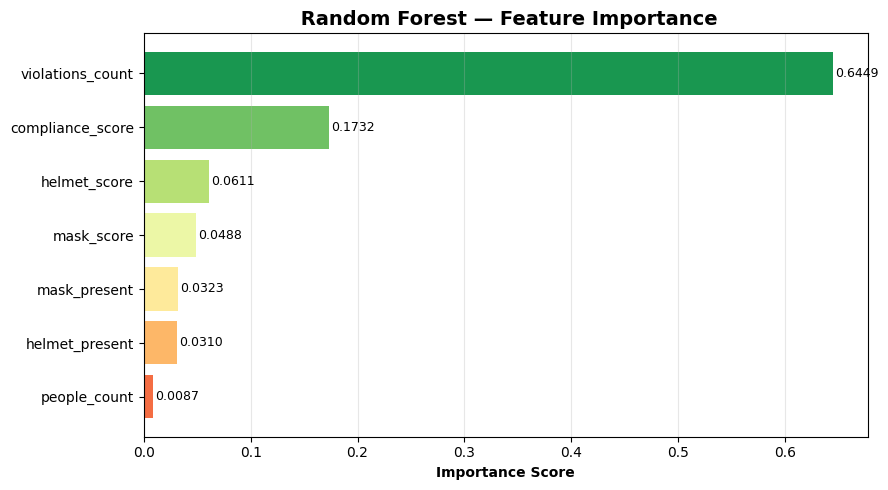

 Feature importance plot saved.


In [8]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title(' Random Forest — Feature Importance', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Feature importance plot saved.")

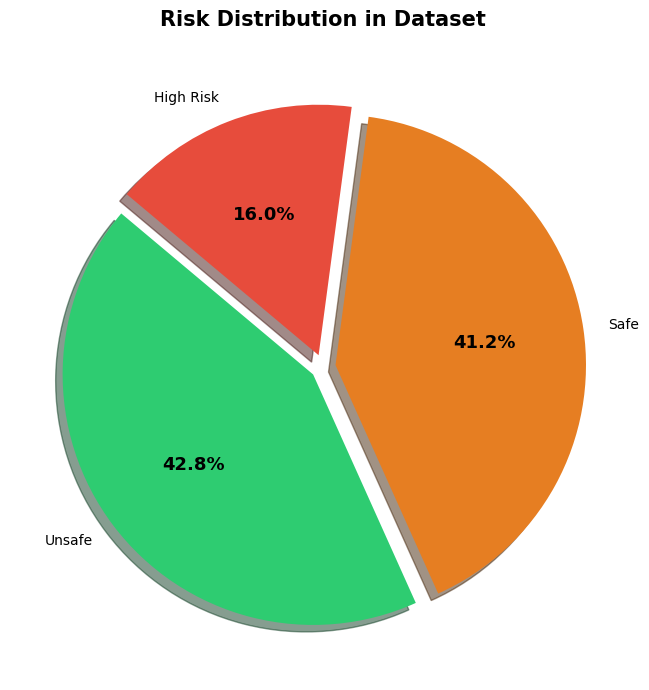

 Risk distribution chart saved.


In [9]:
label_counts = df['risk_label'].value_counts()
colors_pie = ['#2ecc71', '#e67e22', '#e74c3c']  # green, orange, red

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    explode=[0.05, 0.05, 0.05],
    shadow=True
)
for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
ax.set_title('Risk Distribution in Dataset', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Risk distribution chart saved.")

In [10]:
def simulate_ppe_detection():
    """Simulates OpenCV PPE detection output for one video frame."""
    people_count    = random.randint(1, 5)
    helmet_present  = random.choice([0, 1])
    mask_present    = random.choice([0, 1])
    helmet_score    = round(random.uniform(0.7, 1.0) if helmet_present else random.uniform(0.0, 0.4), 2)
    mask_score      = round(random.uniform(0.7, 1.0) if mask_present   else random.uniform(0.0, 0.4), 2)
    violations_count = (1 - helmet_present) + (1 - mask_present)
    compliance_score = round((helmet_score + mask_score) / 2, 2)

    return {
        'helmet_present':  helmet_present,
        'mask_present':    mask_present,
        'helmet_score':    helmet_score,
        'mask_score':      mask_score,
        'violations_count': violations_count,
        'people_count':    people_count,
        'compliance_score': compliance_score
    }


def classify_risk(frame_features):
    """Classify risk level using the trained Random Forest model."""
    features_df = pd.DataFrame([frame_features])[FEATURE_COLS]
    pred_enc    = rf_model.predict(features_df)[0]
    pred_label  = le.inverse_transform([pred_enc])[0]
    return pred_label


def generate_alert(risk_level):
    """Generate alert message based on risk level."""
    alerts = {
        'Safe':      'SAFE      — All workers compliant.',
        'Unsafe':    '  UNSAFE    — PPE violation detected! Supervisor notified.',
        'High Risk': ' HIGH RISK  — Multiple violations! Immediate action required!'
    }
    return alerts.get(risk_level, 'Unknown')


print("Simulating 15 video frames from live webcam feed...")
print("=" * 70)

simulation_log = []
base_time = datetime.now()

for frame_num in range(1, 16):
    features    = simulate_ppe_detection()
    risk        = classify_risk(features)
    alert       = generate_alert(risk)
    timestamp   = (base_time + timedelta(seconds=frame_num * 2)).strftime('%Y-%m-%d %H:%M:%S')

    log_entry = {**{'timestamp': timestamp, 'frame': frame_num}, **features, 'risk_label': risk}
    simulation_log.append(log_entry)

    helmet_str = ' Yes' if features['helmet_present'] else ' No'
    mask_str   = ' Yes' if features['mask_present']   else ' No'

    print(f"Frame {frame_num:02d} | {timestamp}")
    print(f"  People: {features['people_count']}  |  Helmet: {helmet_str}  |  Mask: {mask_str}")
    print(f"  Compliance Score: {features['compliance_score']:.2f}  |  Violations: {features['violations_count']}")
    print(f"  → {alert}")
    print("-" * 70)

print("\n Simulation complete!")

Simulating 15 video frames from live webcam feed...
Frame 01 | 2026-04-30 14:52:02
  People: 4  |  Helmet:  Yes  |  Mask:  No
  Compliance Score: 0.65  |  Violations: 1
  →   UNSAFE    — PPE violation detected! Supervisor notified.
----------------------------------------------------------------------
Frame 02 | 2026-04-30 14:52:04
  People: 1  |  Helmet:  No  |  Mask:  Yes
  Compliance Score: 0.52  |  Violations: 1
  →   UNSAFE    — PPE violation detected! Supervisor notified.
----------------------------------------------------------------------
Frame 03 | 2026-04-30 14:52:06
  People: 1  |  Helmet:  No  |  Mask:  Yes
  Compliance Score: 0.61  |  Violations: 1
  →   UNSAFE    — PPE violation detected! Supervisor notified.
----------------------------------------------------------------------
Frame 04 | 2026-04-30 14:52:08
  People: 4  |  Helmet:  Yes  |  Mask:  Yes
  Compliance Score: 0.94  |  Violations: 0
  → SAFE      — All workers compliant.
--------------------------------------

In [11]:
log_df = pd.DataFrame(simulation_log)
log_path = 'safety_events.csv'
log_df.to_csv(log_path, index=False)

print(f" Safety events saved to '{log_path}'")
print(f"   Total events logged: {len(log_df)}")
print()
log_df[['timestamp', 'frame', 'people_count', 'violations_count', 'compliance_score', 'risk_label']].head(10)

 Safety events saved to 'safety_events.csv'
   Total events logged: 15



,timestamp,frame,people_count,violations_count,compliance_score,risk_label
0,2026-04-30 14:52:02,1,4,1,0.65,Unsafe
1,2026-04-30 14:52:04,2,1,1,0.52,Unsafe
2,2026-04-30 14:52:06,3,1,1,0.61,Unsafe
3,2026-04-30 14:52:08,4,4,0,0.94,Safe
4,2026-04-30 14:52:10,5,4,0,0.86,Safe
5,2026-04-30 14:52:12,6,4,2,0.20,High Risk
6,2026-04-30 14:52:14,7,3,0,0.83,Safe
7,2026-04-30 14:52:16,8,1,2,0.27,High Risk
8,2026-04-30 14:52:18,9,4,1,0.50,Unsafe
9,2026-04-30 14:52:20,10,4,1,0.55,Unsafe


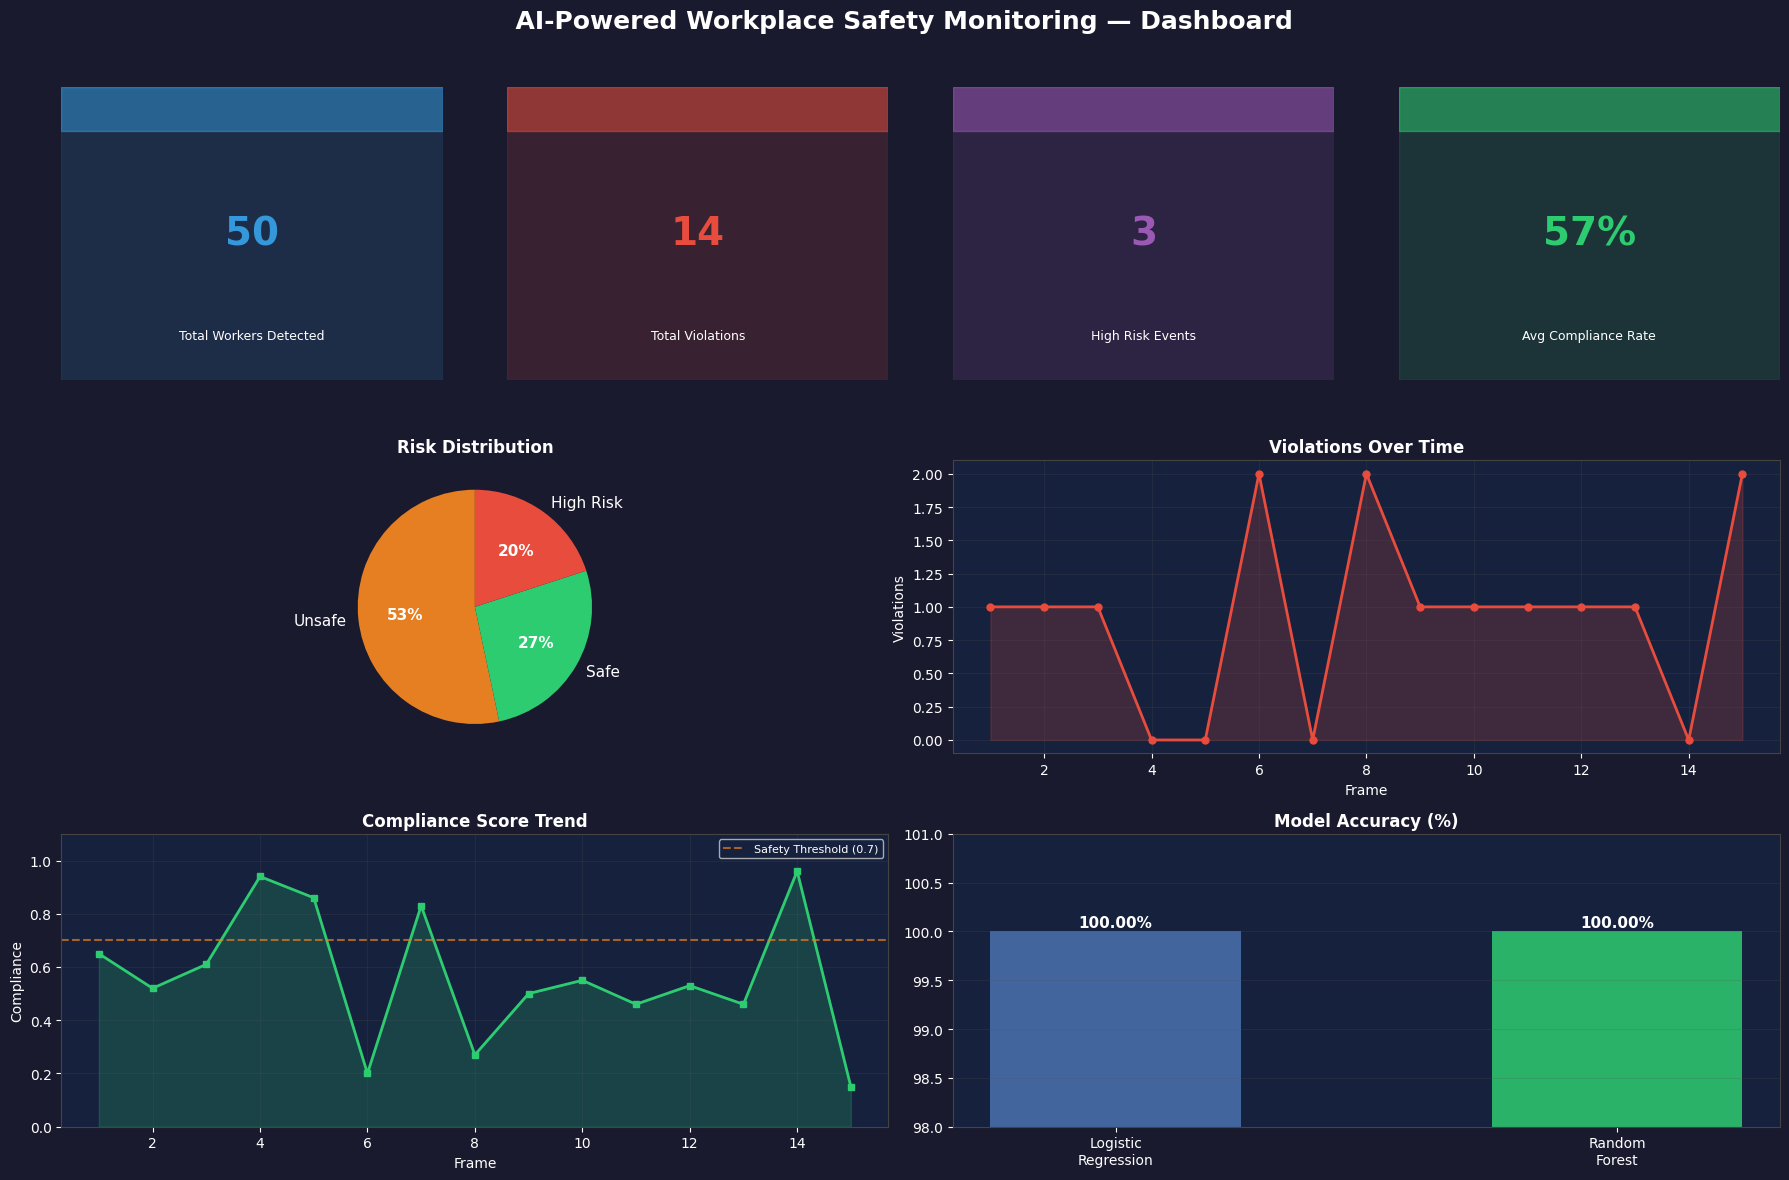

 Safety dashboard saved as safety_dashboard.png


In [12]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('  AI-Powered Workplace Safety Monitoring — Dashboard',
             fontsize=18, fontweight='bold', color='white', y=0.98)

SAFE_COLOR      = '#2ecc71'
UNSAFE_COLOR    = '#e67e22'
HIGHRISK_COLOR  = '#e74c3c'
PANEL_COLOR     = '#16213e'
TEXT_COLOR      = 'white'

risk_counts = log_df['risk_label'].value_counts()
safe_count  = risk_counts.get('Safe', 0)
unsafe_c    = risk_counts.get('Unsafe', 0)
high_risk_c = risk_counts.get('High Risk', 0)
total_workers = log_df['people_count'].sum()
total_viol    = log_df['violations_count'].sum()
avg_compliance = log_df['compliance_score'].mean()

kpi_data = [
    ('Total Workers Detected', total_workers, '#3498db'),
    ('Total Violations',       total_viol,   HIGHRISK_COLOR),
    ('High Risk Events',       high_risk_c,  '#9b59b6'),
    ('Avg Compliance Rate',    f'{avg_compliance:.0%}', SAFE_COLOR),
]
for i, (label, value, color) in enumerate(kpi_data):
    ax = fig.add_subplot(3, 4, i + 1)
    ax.set_facecolor(PANEL_COLOR)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0,0),1,1, color=color, alpha=0.15))
    ax.add_patch(plt.Rectangle((0,0.85),1,0.15, color=color, alpha=0.5))
    ax.text(0.5, 0.5, str(value), ha='center', va='center',
            fontsize=28, fontweight='bold', color=color)
    ax.text(0.5, 0.15, label, ha='center', va='center',
            fontsize=9, color=TEXT_COLOR, wrap=True)

ax_pie = fig.add_subplot(3, 4, (5, 6))
ax_pie.set_facecolor(PANEL_COLOR)
pie_labels = list(risk_counts.index)
pie_vals   = list(risk_counts.values)
pie_colors = [SAFE_COLOR if l == 'Safe' else UNSAFE_COLOR if l == 'Unsafe' else HIGHRISK_COLOR for l in pie_labels]
wedges, texts, autos = ax_pie.pie(pie_vals, labels=pie_labels, autopct='%1.0f%%',
                                   colors=pie_colors, startangle=90,
                                   textprops={'color': TEXT_COLOR, 'fontsize': 11})
for auto in autos:
    auto.set_fontweight('bold')
ax_pie.set_title('Risk Distribution', color=TEXT_COLOR, fontsize=12, fontweight='bold')

ax_line = fig.add_subplot(3, 4, (7, 8))
ax_line.set_facecolor(PANEL_COLOR)
ax_line.plot(log_df['frame'], log_df['violations_count'], color=HIGHRISK_COLOR,
             linewidth=2, marker='o', markersize=5)
ax_line.fill_between(log_df['frame'], log_df['violations_count'],
                      alpha=0.2, color=HIGHRISK_COLOR)
ax_line.set_title('Violations Over Time', color=TEXT_COLOR, fontsize=12, fontweight='bold')
ax_line.set_xlabel('Frame', color=TEXT_COLOR)
ax_line.set_ylabel('Violations', color=TEXT_COLOR)
ax_line.tick_params(colors=TEXT_COLOR)
ax_line.spines[:].set_color('#444')
ax_line.grid(alpha=0.2, color='#555')

ax_comp = fig.add_subplot(3, 4, (9, 10))
ax_comp.set_facecolor(PANEL_COLOR)
ax_comp.plot(log_df['frame'], log_df['compliance_score'], color=SAFE_COLOR,
             linewidth=2, marker='s', markersize=5)
ax_comp.fill_between(log_df['frame'], log_df['compliance_score'],
                      alpha=0.2, color=SAFE_COLOR)
ax_comp.axhline(y=0.7, linestyle='--', color=UNSAFE_COLOR, alpha=0.7, label='Safety Threshold (0.7)')
ax_comp.set_title('Compliance Score Trend', color=TEXT_COLOR, fontsize=12, fontweight='bold')
ax_comp.set_xlabel('Frame', color=TEXT_COLOR)
ax_comp.set_ylabel('Compliance', color=TEXT_COLOR)
ax_comp.set_ylim(0, 1.1)
ax_comp.tick_params(colors=TEXT_COLOR)
ax_comp.spines[:].set_color('#444')
ax_comp.grid(alpha=0.2, color='#555')
ax_comp.legend(facecolor=PANEL_COLOR, labelcolor=TEXT_COLOR, fontsize=8)

ax_mod = fig.add_subplot(3, 4, (11, 12))
ax_mod.set_facecolor(PANEL_COLOR)
model_names = ['Logistic\nRegression', 'Random\nForest']
model_accs  = [lr_acc * 100, rf_acc * 100]
bar_colors  = ['#4C72B0', SAFE_COLOR]
bars_m = ax_mod.bar(model_names, model_accs, color=bar_colors, alpha=0.85, width=0.5)
ax_mod.set_ylim(98, 101)
ax_mod.set_title('Model Accuracy (%)', color=TEXT_COLOR, fontsize=12, fontweight='bold')
ax_mod.tick_params(colors=TEXT_COLOR)
ax_mod.spines[:].set_color('#444')
ax_mod.grid(axis='y', alpha=0.2, color='#555')
for bar, val in zip(bars_m, model_accs):
    ax_mod.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}%', ha='center', color=TEXT_COLOR, fontweight='bold', fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('safety_dashboard.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(" Safety dashboard saved as safety_dashboard.png")

In [13]:
def predict_risk_from_input(helmet_present, mask_present, people_count=2):
    """
    Predict workplace risk from PPE input values.
    
    Args:
        helmet_present (int): 1 if helmet worn, 0 if not
        mask_present   (int): 1 if mask worn, 0 if not
        people_count   (int): number of workers (1-5)
    """
    helmet_score     = 0.85 if helmet_present else 0.2
    mask_score       = 0.85 if mask_present   else 0.2
    violations_count = (1 - helmet_present) + (1 - mask_present)
    compliance_score = round((helmet_score + mask_score) / 2, 2)

    features = {
        'helmet_present':  helmet_present,
        'mask_present':    mask_present,
        'helmet_score':    helmet_score,
        'mask_score':      mask_score,
        'violations_count': violations_count,
        'people_count':    people_count,
        'compliance_score': compliance_score
    }

    risk = classify_risk(features)
    alert = generate_alert(risk)

    print("=" * 50)
    print(" RISK PREDICTION RESULT")
    print("=" * 50)
    print(f"  Helmet Present   : {' Yes' if helmet_present else ' No'}")
    print(f"  Mask Present     : {' Yes' if mask_present   else ' No'}")
    print(f"  People Count     : {people_count}")
    print(f"  Compliance Score : {compliance_score:.2f}")
    print(f"  Violations       : {violations_count}")
    print("-" * 50)
    print(f"  Risk Level       : {risk}")
    print(f"  Alert            : {alert}")
    print("=" * 50)


print("\n SCENARIO 1: Both PPE present")
predict_risk_from_input(helmet_present=1, mask_present=1, people_count=3)

print("\n SCENARIO 2: Only helmet, no mask")
predict_risk_from_input(helmet_present=1, mask_present=0, people_count=2)

print("\n SCENARIO 3: No PPE at all")
predict_risk_from_input(helmet_present=0, mask_present=0, people_count=4)


 SCENARIO 1: Both PPE present
 RISK PREDICTION RESULT
  Helmet Present   :  Yes
  Mask Present     :  Yes
  People Count     : 3
  Compliance Score : 0.85
  Violations       : 0
--------------------------------------------------
  Risk Level       : Safe
  Alert            : SAFE      — All workers compliant.

 SCENARIO 2: Only helmet, no mask
 RISK PREDICTION RESULT
  Helmet Present   :  Yes
  Mask Present     :  No
  People Count     : 2
  Compliance Score : 0.53
  Violations       : 1
--------------------------------------------------
  Risk Level       : Unsafe
  Alert            :   UNSAFE    — PPE violation detected! Supervisor notified.

 SCENARIO 3: No PPE at all
 RISK PREDICTION RESULT
  Helmet Present   :  No
  Mask Present     :  No
  People Count     : 4
  Compliance Score : 0.20
  Violations       : 2
--------------------------------------------------
  Risk Level       : High Risk
  Alert            :  HIGH RISK  — Multiple violations! Immediate action required!


In [14]:
print("=" * 65)
print("        AI-POWERED WORKPLACE SAFETY MONITORING")
print("              FINAL SUMMARY REPORT")
print("=" * 65)

print(f"\n Dataset")
print(f"   Total Samples  : {len(df)}")
print(f"   Features Used  : {len(FEATURE_COLS)}")
print(f"   Train / Test   : {len(X_train)} / {len(X_test)} (80/20 split)")

print(f"\n Model Performance")
print(f"   {'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"   {'-'*63}")
print(f"   {'Logistic Regression':<25} {lr_acc*100:>9.2f}% {lr_prec*100:>9.2f}% {lr_rec*100:>7.2f}% {lr_f1*100:>7.2f}%")
print(f"   {'Random Forest':<25} {rf_acc*100:>9.2f}% {rf_prec*100:>9.2f}% {rf_rec*100:>7.2f}% {rf_f1*100:>7.2f}%")

print(f"\n Best Model   : Random Forest")
print(f"   Final Model   : rf_model (Scikit-learn RandomForestClassifier)")

print(f"\n Simulation Results ({len(simulation_log)} frames)")
sim_risk_dist = log_df['risk_label'].value_counts()
for label, count in sim_risk_dist.items():
    pct = count / len(log_df) * 100
    icon = 'pass' if label == 'Safe' else 'problem' if label == 'Unsafe' else 'cant pass'
    print(f"   {icon} {label:<12}: {count} frames ({pct:.1f}%)")

print(f"\n Output Files")
for fname in ['safety_events.csv', 'model_comparison.png',
              'feature_importance.png', 'risk_distribution.png',
              'safety_dashboard.png']:
    exists = 'right' if os.path.exists(fname) else 'wrong'
    print(f"   {exists} {fname}")

print("\n" + "=" * 65)

print("=" * 65)

        AI-POWERED WORKPLACE SAFETY MONITORING
              FINAL SUMMARY REPORT

 Dataset
   Total Samples  : 600
   Features Used  : 7
   Train / Test   : 480 / 120 (80/20 split)

 Model Performance
   Model                       Accuracy  Precision   Recall       F1
   ---------------------------------------------------------------
   Logistic Regression          100.00%    100.00%  100.00%  100.00%
   Random Forest                100.00%    100.00%  100.00%  100.00%

 Best Model   : Random Forest
   Final Model   : rf_model (Scikit-learn RandomForestClassifier)

 Simulation Results (15 frames)
   problem Unsafe      : 8 frames (53.3%)
   pass Safe        : 4 frames (26.7%)
   cant pass High Risk   : 3 frames (20.0%)

 Output Files
   right safety_events.csv
   right model_comparison.png
   right feature_importance.png
   right risk_distribution.png
   right safety_dashboard.png

